<h1 align="center">Project 1: Advanced EDA & Feature Engineering</h1>

<p align="center"><b>Dataset Used:</b> Titanic Dataset</p>

<p align="center">
The Titanic dataset was selected because the project did not provide a specific dataset.
It is widely used for Exploratory Data Analysis, missing value handling, outlier detection, and feature engineering.
</p>


**REQUIREMENT-1 : HANDLE MISSING DATA(STATISTICAL IMPUTATION**)

In [12]:
 import pandas as pd
 import numpy as np
 df=pd.read_csv("train[1].csv")
 df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
from google.colab import files
uploaded = files.upload()

Saving train[1].csv to train[1] (1).csv


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**MISSING VALUE HANDLING**

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Fill missing values in Age

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Fill missing values in Embarked

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Handle the Cabin column

In [ ]:
df.drop('Cabin', axis=1, inplace=True)

Checking whether all missing values are handled



In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**REQUIREMENT-2 : Identify and neutralize outliers using Z-Scores or the Interquartile Range (IQR).**

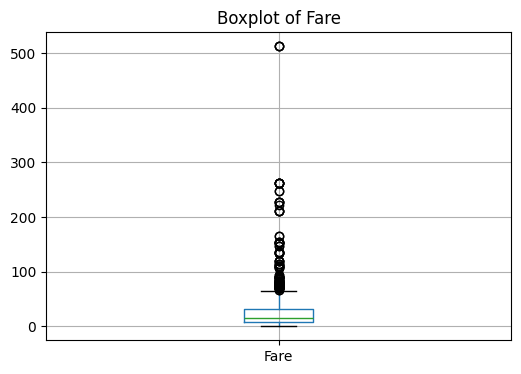

In [ ]:
#Check outliers in the Fare column
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df.boxplot(column='Fare')
plt.title("Boxplot of Fare")
plt.show()

Calculate the IQR

In [ ]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Q1 = 7.9104
Q3 = 31.0
IQR = 23.0896
Lower Bound = -26.724
Upper Bound = 65.6344


(Remove) the Outliers

In [ ]:
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

Verify the Result

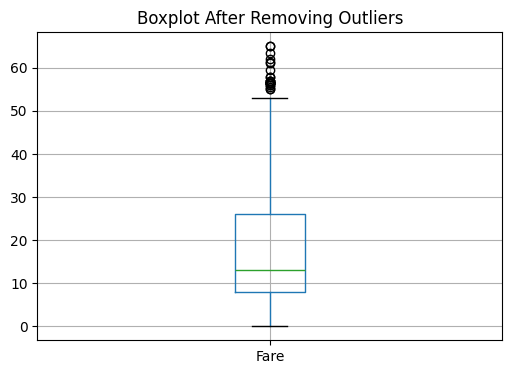

In [ ]:
plt.figure(figsize=(6,4))
df.boxplot(column='Fare')
plt.title("Boxplot After Removing Outliers")
plt.show()

**FINAL REQUIREMENT- 3: Feature Engineering**

In [ ]:
#1. FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
#2. IsAlone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [ ]:
#3. AgeGroup
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

 **To check the new features:**

In [ ]:
df[['FamilySize','IsAlone','AgeGroup']].head()


,FamilySize,IsAlone,AgeGroup
0,2,0,Young Adult
2,1,1,Young Adult
3,2,0,Young Adult
4,1,1,Young Adult
5,1,1,Young Adult


To Verify the Final Dataset

1. Check the first 5 rows

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Young Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Young Adult
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,1,1,Young Adult


2. Check the dataset information

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  775 non-null    int64   
 1   Survived     775 non-null    int64   
 2   Pclass       775 non-null    int64   
 3   Name         775 non-null    object  
 4   Sex          775 non-null    object  
 5   Age          775 non-null    float64 
 6   SibSp        775 non-null    int64   
 7   Parch        775 non-null    int64   
 8   Ticket       775 non-null    object  
 9   Fare         775 non-null    float64 
 10  Embarked     775 non-null    object  
 11  FamilySize   775 non-null    int64   
 12  IsAlone      775 non-null    int64   
 13  AgeGroup     775 non-null    category
dtypes: category(1), float64(2), int64(7), object(4)
memory usage: 85.7+ KB


3. Check missing values one last time

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Final Step: Saving the Cleaned Dataset**

In [10]:
df.to_csv("cleaned_titanic.csv", index=False)

In [20]:
!ls

 cleaned_titanic.csv   sample_data  'train[1].csv'
